In [42]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

import shap

In [60]:

df = pd.read_csv(
    "/content/drive/MyDrive/Kaggle Analytics/users_all.csv",
    sep=";",
    quotechar='"'
)

df.head()

,account_id,industry,country,signup_date,plan_tier,seats,is_trial,churn_flag,total_mrr,total_arr,...,total_usage,total_usage_time,total_errors,total_tickets,avg_resolution_time,avg_first_response_time,avg_csat,escalations,tenure_months,revenue_per_seat
0,A-2e4581,EdTech,US,2024-10-16,Basic,9,0,0,12603.0,151236.0,...,426.0,126396.0,28.0,2,23.000000,91.0000,1.5000,0.0,16,1400.3333
1,A-43a9e3,FinTech,IN,2023-08-17,Basic,18,0,1,10004.0,120048.0,...,340.0,93594.0,14.0,3,38.000000,73.3333,4.0000,0.0,30,555.7778
2,A-0a282f,DevTools,US,2024-08-27,Basic,1,0,0,18286.0,219432.0,...,696.0,209585.0,39.0,3,43.666667,63.6667,4.6667,0.0,18,18286.0000
3,A-1f0ac7,HealthTech,UK,2023-08-27,Basic,24,1,0,9275.0,111300.0,...,342.0,96649.0,19.0,2,29.000000,174.0000,0.0000,0.0,30,386.4583
4,A-ce550d,HealthTech,US,2024-10-27,Enterprise,35,0,1,48761.0,585132.0,...,450.0,175918.0,26.0,7,42.285714,107.8571,2.7143,1.0,16,1393.1714


In [61]:
# CLEAN DATA

account_ids = df["account_id"]

# Drop ID
df = df.drop(columns=["account_id"], errors="ignore")


# Convert churn to int
df["churn_flag"] = df["churn_flag"].astype(int)

# Convert signup_date properly
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month

# Drop raw date
df = df.drop(columns=["signup_date"])

# Define X and y
X = df.drop(columns=["churn_flag"])
y = df["churn_flag"]

In [62]:
# TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [63]:
# PREPROCESSING PIPELINE

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [64]:
# MODEL 1: LOGISTIC REGRESSION

log_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_pipeline.fit(X_train, y_train)

log_pred = log_pipeline.predict(X_test)
log_proba = log_pipeline.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_proba))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.81      0.59      0.68       117
           1       0.26      0.52      0.35        33

    accuracy                           0.57       150
   macro avg       0.54      0.55      0.52       150
weighted avg       0.69      0.57      0.61       150

ROC-AUC: 0.5545195545195545


In [65]:
# MODEL 2: RANDOM FOREST

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:,1]

print("\nRANDOM FOREST")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       117
           1       1.00      0.03      0.06        33

    accuracy                           0.79       150
   macro avg       0.89      0.52      0.47       150
weighted avg       0.83      0.79      0.70       150

ROC-AUC: 0.6298886298886299


In [66]:
# MODEL 3 -XGBOOST

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:,1]

print("\nXGBOOST")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))


XGBOOST
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       117
           1       0.21      0.12      0.15        33

    accuracy                           0.71       150
   macro avg       0.49      0.50      0.49       150
weighted avg       0.65      0.71      0.68       150

ROC-AUC: 0.5653975653975654


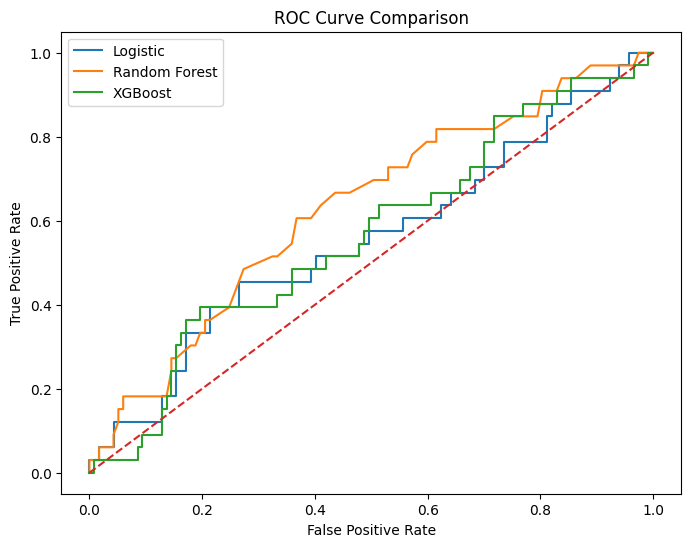

In [67]:
# ROC CURVE COMPARISON

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

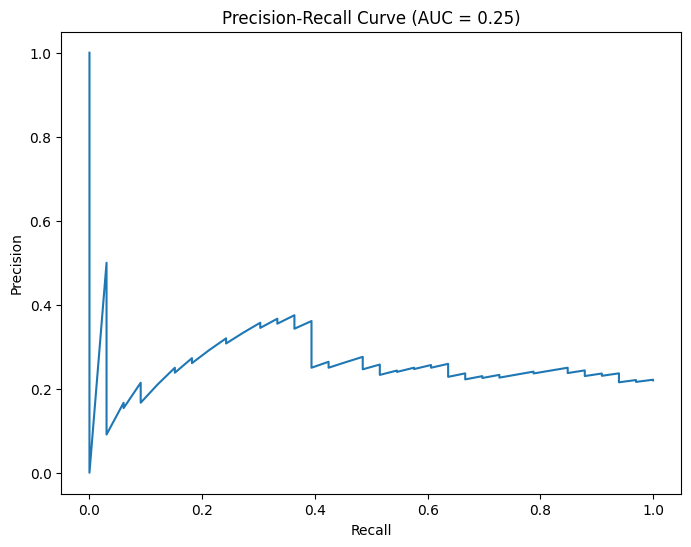

In [68]:
# PRECISION - RECALL CURVE

precision, recall, _ = precision_recall_curve(y_test, xgb_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.2f})")
plt.show()

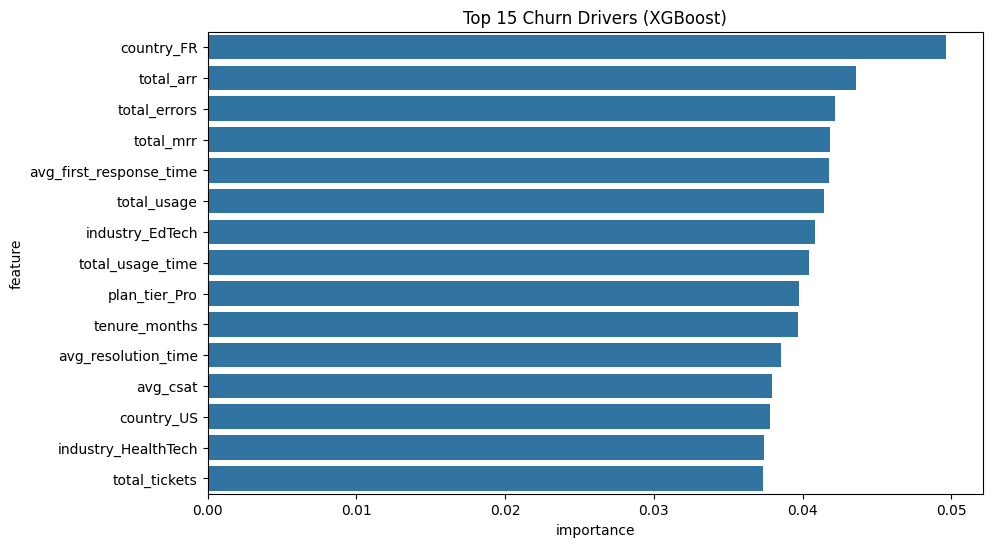

In [69]:
# FEATURE IMPORTANCE (XGBoost)

xgb_model = xgb_pipeline.named_steps["model"]

feature_names = (
    numeric_features.tolist() +
    xgb_pipeline.named_steps["preprocessing"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Churn Drivers (XGBoost)")
plt.show()

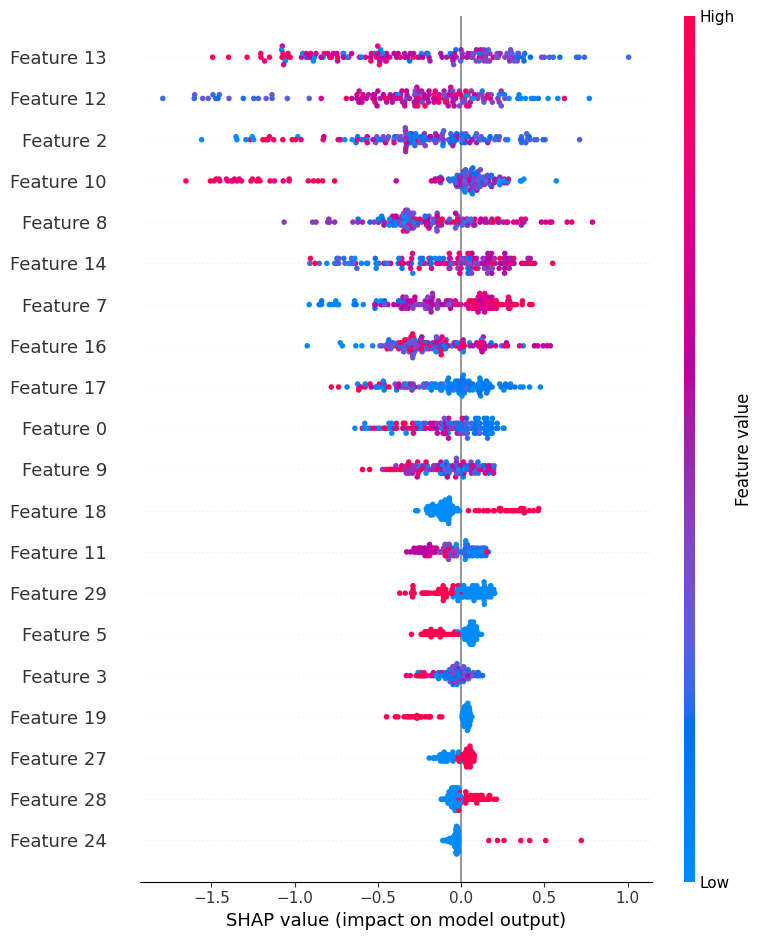

In [70]:
# SHAP EXPLAINABILITY

X_test_transformed = xgb_pipeline.named_steps["preprocessing"].transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)

In [71]:
# CHURN PROBABILITY SCORE

churn_proba_full = xgb_pipeline.predict_proba(X)[:,1]

scoring_df = pd.DataFrame({
    "account_id": account_ids,
    "churn_probability": churn_proba_full
})

# Add risk segmentation
scoring_df["risk_segment"] = pd.qcut(
    scoring_df["churn_probability"],
    q=3,
    labels=["Low", "Medium", "High"]
)

scoring_df.head()

,account_id,churn_probability,risk_segment
0,A-2e4581,0.038018,Low
1,A-43a9e3,0.902859,High
2,A-0a282f,0.059712,Low
3,A-1f0ac7,0.083078,Medium
4,A-ce550d,0.922714,High


In [72]:
# Score full dataset (all accounts)
full_proba = xgb_pipeline.predict_proba(X)[:, 1]

scoring_df = pd.DataFrame({
    "account_id": account_ids,
    "churn_flag": y,
    "churn_probability": full_proba,
    "total_mrr": df["total_mrr"]
})

In [73]:
active_accounts = scoring_df[scoring_df["churn_flag"] == 0].copy()

In [74]:
active_accounts["risk_segment"] = np.where(
    active_accounts["churn_probability"] >= 0.7, "High",
    np.where(active_accounts["churn_probability"] >= 0.4, "Medium", "Low")
)

In [75]:
active_accounts["revenue_at_risk"] = (
    active_accounts["churn_probability"] * active_accounts["total_mrr"]
)

In [76]:
top_risk_accounts = active_accounts.sort_values(
    "revenue_at_risk",
    ascending=False
).head(10)

top_risk_accounts

,account_id,churn_flag,churn_probability,total_mrr,risk_segment,revenue_at_risk
330,A-acb7f7,0,0.865744,32574.0,High,28200.735176
347,A-e3bd71,0,0.604664,41630.0,Medium,25172.170917
76,A-02cd81,0,0.739841,32956.0,High,24382.211266
403,A-d4e0d4,0,0.163231,138060.0,Low,22535.628700
352,A-a33200,0,0.728727,28913.0,High,21069.691878
53,A-c1dfe1,0,0.676152,25790.0,Medium,17437.953696
447,A-7c83a1,0,0.907928,16731.0,High,15190.548186
183,A-1619f8,0,0.759011,19790.0,High,15020.828288
133,A-9f9299,0,0.317961,42403.0,Low,13482.479112
459,A-a09355,0,0.371460,34140.0,Low,12681.647136
